# [`pandas.DataFrame` Based Datasets](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#)


[This tutorial](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html) covers how to use GluonTS's [`pandas.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)-based dataset: the
[`PandasDataset`](https://ts.gluon.ai/stable/api/gluonts/gluonts.dataset.pandas.html?highlight=pandasdataset#gluonts.dataset.pandas.PandasDataset). After going through a few common use cases, we explain in detail what data formats `PandasDataset` can work with, how to include static and dynamic features, and how to do train/test splits.

## [Introduction](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Introduction)

The GluonTS `PandasDataset` works with a `pandas.DataFrame`, `pandas.Series` or any collection of both.
The minimum requirements to start modeling using GluonTS's dataframe dataset are

1. A list of monotonically increasing timestamps with a fixed frequency
2. A list of corresponding target values in the `pandas.DataFrame`

|timestamp|target|
|----|----|
|2021-01-01 00:00:00|-0.21|
|2021-01-01 01:00:00|-0.33|
|2021-01-01 02:00:00|-0.33|
|...|...|

### Static and Dynamic Features

If you have additional dynamic or static features, you can include those in separate columns like this:

|timestamp|target|stat_cat_1|dyn_real_1|
|----|----|----|----|
|2021-01-01 00:00:00|-0.21|0|0.79|
|2021-01-01 01:00:00|-0.33|0|0.59|
|2021-01-01 02:00:00|-0.33|0|0.39|
|...|...|...|...|

### Multiple Time Series

Multiple time series can be combined into a single GluonTS `PandasDataset`. This can be done by creating one of the following:
- a list of the DataFrames with the format above (each DataFrame has at least a `timestamp` index or column and `target` column)
- a dict of DataFrames
    - When using a dict, the keys are used as `item_id`s.
- or a Long-DataFrame that has an additional `item_id` column that groups the different time series

Here's an example of combining two time series into one `PandasDataset`:

|timestamp|target|item_id|stat_cat_1|dyn_real_1|
|----|----|----|----|----|
|2021-01-01 00:00:00|-0.21|A|0|0.79|
|2021-01-01 01:00:00|-0.33|A|0|0.59|
|2021-01-01 02:00:00|-0.33|A|0|0.39|
|2021-01-01 01:00:00|-1.24|B|1|-0.60|
|2021-01-01 02:00:00|-1.37|B|1|-0.91|

- The time series values are represented by the `target` column
- The corresponding timestamp values are in the `timestamp` column
- The `item_id` column indicates which time series a specific row belongs to
    - The first time series is denoted using `item_id` = A
    - The second time series is denoted using `item_id` = B
- If we have other features we can include those too (`stat_cat_1` and `dyn_real_1` in the example above)

## [Use Case 1: Loading Data From a `long` DataFrame](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Use-case-1---Loading-data-from-a-long-dataframe)

In the first use case, we are given data in the `long` format. I.e., we're given multiple time series stacked on top of each other in a `pandas.DataFrame` with an `item_id` column that identifies which time series each row belongs to.

In [46]:
import pandas as pd

# Define url to read csv file from
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)

# Read csv file into dataframe
df = pd.read_csv(url, index_col=0, parse_dates=True)
df.head()

,target,item_id
2021-01-01 00:00:00,-1.3378,A
2021-01-01 01:00:00,-1.6111,A
2021-01-01 02:00:00,-1.9259,A
2021-01-01 03:00:00,-1.9184,A
2021-01-01 04:00:00,-1.9168,A


Here are the `item_id`s of all the time series

In [47]:
print(sorted(df["item_id"].unique()))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


After reading the data into a `pandas.DataFrame`, we can easily convert
it to `gluonts.dataset.pandas.PandasDataset` and train an estimator an get forecasts.

In [48]:
from gluonts.dataset.pandas import PandasDataset

ds = PandasDataset.from_long_dataframe(df, target="target", item_id="item_id")

## [Use Case 2: Loading Data With Missing Values](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Use-case-2---Loading-data-with-missing-values)

If the `timestamp` column is not evenly spaced and monotonically increasing, we get an error when using `PandasDataset`. Here we'll fill in the missing values.

First, let's remove some random rows from the `long` dataset.

In [49]:
import pandas as pd
import numpy as np

# Url to read csv file from
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)

# Read csv file into dataframe
df = pd.read_csv(url, index_col=0, parse_dates=True)

# Compute random indices to remove
remove_indices = np.random.choice(np.arange(df.shape[0]), size=100, replace=False)

# Create a mask to apply to the dataframe
mask = [False if i in remove_indices else True for i in range(df.shape[0])]

# Apply the mask to the dataframe to remove the randomly selected indices
df_missing_val = df.loc[mask, :]

df_missing_val.head()

,target,item_id
2021-01-01 00:00:00,-1.3378,A
2021-01-01 01:00:00,-1.6111,A
2021-01-01 02:00:00,-1.9259,A
2021-01-01 03:00:00,-1.9184,A
2021-01-01 05:00:00,-1.9681,A


Then, we'll group the rows in the dataframe `item_id` and reindex each of the grouped dataframes. Reindexing, as it's done below, will add new rows with `NaN` values where
the data is missing. The user can then use the `fillna()` method on each dataframe to fill in desired value.

In [50]:
from gluonts.dataset.pandas import PandasDataset

# Compute the maximum ending timestamp among all time series
max_end_timestamp = max(df.groupby("item_id").apply(lambda _df: _df.index[-1]))

# Map item_ids to cleaned, reindexed dataframes
cleaned_dfs = {}

# Iterate through each of the item_id groups
for item_id, grouped_dataframe in df_missing_val.groupby("item_id"):
    # Create a new time index that spans from the first timestamp in the
    # group_dataframe to max_end_timestamp
    start_timestamp = grouped_dataframe.index[0]
    new_index = pd.date_range(
        start_timestamp,
        end=max_end_timestamp,
        freq="1H",
    )

    # Reindex the grouped dataframe and remove the "item_id" column
    cleaned_df = grouped_dataframe.reindex(new_index).drop("item_id", axis=1)

    # Add the cleaned dataframe to the cleaned dataframes dictionary
    cleaned_dfs[item_id] = cleaned_df

# Create a GluonTS PandasDataset from the cleaned dataframes dictionary
ds = PandasDataset(cleaned_dfs, target="target")

## [Use Case 3: Loading Data From a `wide` DataFrame](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Use-case-3---Loading-data-from-a-wide-dataframe)

Here, we are given data in the `wide` format. I.e. time series are stacked side-by-side in a `DataFrame`.

In [51]:
import pandas as pd

# Url for the wide csv file
url_wide = (
    "https://gist.githubusercontent.com/rsnirwan/c8c8654a98350fadd229b00167174ec4"
    "/raw/a42101c7786d4bc7695228a0f2c8cea41340e18f/ts_wide.csv"
)

# Read csv file into dataframe
df_wide = pd.read_csv(url_wide, index_col=0, parse_dates=True)
df_wide.head()

,A,B,C,D,E,F,G,H,I,J
2021-01-01 00:00:00,-1.3378,0.1268,-0.3645,-1.0864,-2.3803,-0.2447,2.2647,-0.7917,0.7071,1.3763
2021-01-01 01:00:00,-1.6111,0.0926,-0.1364,-1.1613,-2.1421,-0.3477,2.4262,-0.9609,0.6413,1.2750
2021-01-01 02:00:00,-1.9259,-0.1420,0.1063,-1.0405,-2.1426,-0.3271,2.4434,-0.9034,0.4323,0.6767
2021-01-01 03:00:00,-1.9184,-0.4930,0.6269,-0.8531,-1.7060,-0.3088,2.4307,-0.9602,0.3193,0.5150
2021-01-01 04:00:00,-1.9168,-0.5057,0.9419,-0.7666,-1.4287,-0.4284,2.3258,-1.2504,0.3660,0.1708


We can simply turn the wide dataframe into a dictionary of `Series` objects with `dict`, and construct a `PandasDataset`.

In [52]:
from gluonts.dataset.pandas import PandasDataset

ds = PandasDataset(dict(df_wide))

## [Other Use Cases](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#General-use-cases)

Here, we explain in detail what data formats `PandasDataset` can work with, how to include static and dynamic features, and how to create train/test splits.

### [How to: Generate Dummy Data](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Dummy-data-generation)

Let's create a function `generate_single_ts()` that generates a dummy time series conforming to the requirements state above (i.e. each time series needs a `timestamp` index and `target` column).


This function randomly samples sin/cos curves and outputs their sum. You don't need to understand how this really works. We will just call `generate_single_ts()` with datetime values which rise monotonically with fixed frequency and get a `pandas.DataFrame` with `timestamp` and `target` values.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def generate_single_ts(date_range, item_id=None) -> pd.DataFrame:
    """create sum of `n_f` sin/cos curves with random scale and phase."""
    n_f = 2
    period = np.array([24 / (i + 1) for i in range(n_f)]).reshape(1, n_f)
    scale = np.random.normal(1, 0.3, size=(1, n_f))
    phase = 2 * np.pi * np.random.uniform(size=(1, n_f))
    periodic_f = lambda x: scale * np.sin(np.pi * x / period + phase)

    t = np.arange(0, len(date_range)).reshape(-1, 1)
    target = periodic_f(t).sum(axis=1) + np.random.normal(0, 0.1, size=len(t))
    ts = pd.DataFrame({"target": target}, index=date_range)
    if item_id is not None:
        ts["item_id"] = item_id
    return ts

In [54]:
# Prediction window
prediction_length = 24

# Time series frequency
freq = "1H"

# Number of periods in the time series
periods = 10 * prediction_length

# Create the timestamps for our time series
date_range = pd.date_range("2021-01-01", periods=periods, freq=freq)

# Create time series of randomly generated data
time_series = generate_single_ts(date_range)

print(f"type(time_series): {type(time_series)}")
print(f"time_series.shape: {time_series.shape}")
time_series.head()

type(time_series): <class 'pandas.core.frame.DataFrame'>
time_series.shape: (240, 1)


,target
2021-01-01 00:00:00,-0.179158
2021-01-01 01:00:00,-0.600880
2021-01-01 02:00:00,-0.841111
2021-01-01 03:00:00,-1.143315
2021-01-01 04:00:00,-1.399145


Create a plot of our dummy time series

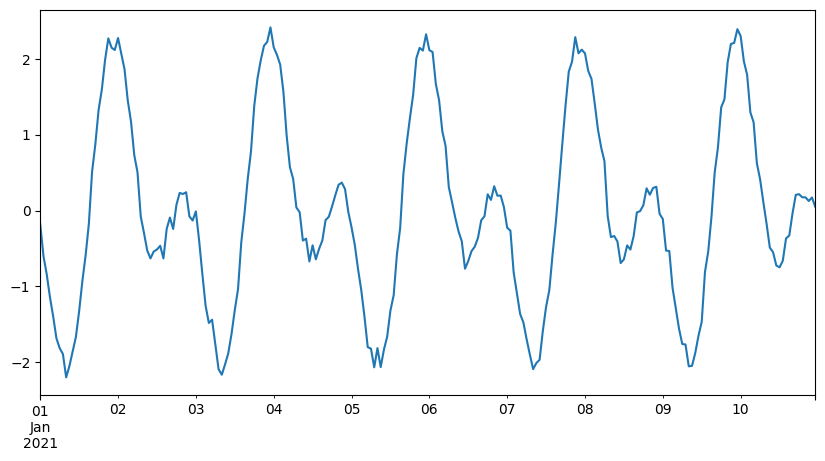

In [55]:
time_series.loc[:, "target"].plot(figsize=(10, 5));

### [How to: Use a Single Time Series For Training](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Use-single-time-series-for-training)

Now, we'll create a GluonTS dataset using the time series we generated and train
a model on it.

In [56]:
from gluonts.torch import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions, Evaluator

"""
Create a function to train the model and compute a forecast
"""


def train_and_predict(dataset, estimator):
    # Train the estimator the get a predictor
    predictor = estimator.train(dataset)

    # Use the predictor to compute forecasts
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=dataset, predictor=predictor
    )
    evaluator = Evaluator(quantiles=(np.arange(20) / 20.0)[1:])

    # Return the MSE
    agg_metrics, item_metrics = evaluator(ts_it, forecast_it, num_series=len(dataset))
    return agg_metrics["MSE"]


# Create a PandasDataset
dataset = PandasDataset(time_series, target="target", freq=freq)

trainer_kwargs = {
    "max_epochs": 1,
}

# Create a DeepAR model
estimator = DeepAREstimator(
    freq=freq, prediction_length=prediction_length, trainer_kwargs=trainer_kwargs
)

# Train and predict the model for one epoch
train_and_predict(dataset, estimator)

/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mike_gee/miniconda3/envs/tempo/lib/python3.8/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 744, 5], [1, 744], [1,

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 1.28919 (best 1.28919), saving model to '/home/mike_gee/TEMPO/gluon/tutorials/lightning_logs/version_22/checkpoints/epoch=0-step=50.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=1` reached.
/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We

0.05938257591024918

### [How to: Use Multiple Time Series For Training](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Use-multiple-time-series-for-training)

We can also use a list of single time series dataframes. Even a dict of dataframes or a single long-formatted-dataframe with multiple time series can be used.
L et's create multiple time series and train the model using those.

In [57]:
# Number of time series to create
num_time_series = 10

# Create a list where each element is a pandas dataframe containing a time series
time_series_list = [generate_single_ts(date_range) for _ in range(num_time_series)]

# Convert the list of time series into a GluonTS PandasDataset
dataset = PandasDataset(time_series_list, target="target", freq=freq)
train_and_predict(dataset, estimator)

/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mike_gee/miniconda3/envs/tempo/lib/python3.8/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 744, 5], [1, 744], [1, 744], [1, 24, 5]] | [1, 100, 24]
-----------------------------------------------------------------------------------------------------------------------------
27.6 K    Trainable params
0         Non-trainable params
27.6 K    Total params
0.111     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 1.15764 (best 1.15764), saving model to '/home/mike_gee/TEMPO/gluon/tutorials/lightning_logs/version_23/checkpoints/epoch=0-step=50.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=1` reached.
/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We

0.10174113638397939

If the dataset is given as a long-dataframe, we can also use an
alternative constructor `from_long_dataframe`. Note in this case
we have to provide the `item_id` as well.

In [58]:
# Create a long dataframe
long_df = pd.concat(
    [generate_single_ts(date_range, item_id=i) for i in range(num_time_series)]
)

long_df.head()

,target,item_id
2021-01-01 00:00:00,0.253915,0
2021-01-01 01:00:00,0.038234,0
2021-01-01 02:00:00,-0.373439,0
2021-01-01 03:00:00,-0.625760,0
2021-01-01 04:00:00,-0.878104,0


Here are the `item_id`s of all the time series

In [59]:
print(sorted(long_df["item_id"].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Note: we need to provide an `item_id` column and the name of the `item_id` column the `PandasDataset` constructor. Otherwise, there wouldn't be a way to distinguish the different time series.

In [60]:
# Create a GluonTS PandasDataset using the long dataframe
dataset = PandasDataset.from_long_dataframe(
    long_df,
    item_id="item_id",
    target="target",
    freq=freq,
)
train_and_predict(dataset, estimator)

/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mike_gee/miniconda3/envs/tempo/lib/python3.8/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 744, 5], [1, 744], [1,

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 1.07792 (best 1.07792), saving model to '/home/mike_gee/TEMPO/gluon/tutorials/lightning_logs/version_24/checkpoints/epoch=0-step=50.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=1` reached.
/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We

0.15485832379675699

### [How to: Include Static and Dynamic Features](https://ts.gluon.ai/stable/tutorials/data_manipulation/pandasdataframes.html#Include-static-and-dynamic-features)

The PandasDataset also allows us to include features of our time series. The list of all available features is given in the [documentation](https://ts.gluon.ai/stable/api/gluonts/gluonts.dataset.pandas.html?highlight=pandasdataset#gluonts.dataset.pandas.PandasDataset). Here, we use dynamic real and static categorical features. To mimic those features we'll just wrap our fancy data generator `generate_single_ts()` and add a static cat and two dynamic real features.

In [61]:
def generate_single_ts_with_features(date_range, item_id) -> pd.DataFrame:
    ts = generate_single_ts(date_range, item_id)
    T = ts.shape[0]
    # static features are constant for each series
    ts["dynamic_real_1"] = np.random.normal(size=T)
    ts["dynamic_real_2"] = np.random.normal(size=T)
    # ... we can have as many static or dynamic features as we like
    return ts


df = generate_single_ts_with_features(date_range, item_id=0)
df.head()

,target,item_id,dynamic_real_1,dynamic_real_2
2021-01-01 00:00:00,-0.000107,0,0.779873,0.078868
2021-01-01 01:00:00,-0.241982,0,0.348977,-1.971141
2021-01-01 02:00:00,-0.274304,0,0.659741,0.888064
2021-01-01 03:00:00,-0.475823,0,0.741711,0.003599
2021-01-01 04:00:00,-0.512665,0,-0.721975,-1.884389


Now, when we create the GluonTS dataset, we need to tell the constructor which columns are the categorical and real features. Also, we need to let the `estimator` know that more features are coming in. 

Note: if categorical features are provided, `DeepAR` also needs the cardinality as input. We have one static categorical feature that can take on two values (0 or 1). The cardinality in this case is a list of one element: `[2,]`.

In [62]:
estimator_with_features = DeepAREstimator(
    freq=dataset.freq,
    prediction_length=prediction_length,
    num_feat_dynamic_real=2,
    num_feat_static_cat=1,
    cardinality=[2],
    trainer_kwargs=trainer_kwargs,
)

Let's now generate multiple time series, both as a dictionary of data frames
and as a single long data frame. We'll also generate a dedicated data frame of
static features.


Note: we don't provide `freq` and `timestamp`, because they are automatically inferred from the time index. We are also not passing the `target` argument, since
it's default value is "target", which is the target column in our dataframes.

In [63]:
# Create a dictionary of time series
time_series_dict = {
    i: generate_single_ts_with_features(date_range, item_id=i) for i in range(num_time_series)
}

# Create a dataframe for the static features
static_features = pd.DataFrame(
    {
        "color": pd.Categorical(np.random.choice(["red", "green", "blue"], size=num_time_series)),
        "height": np.random.normal(loc=100, scale=15, size=num_time_series),
    },
    index=list(time_series_dict.keys()),
)

# Create a long dataframe
long_df = pd.concat(time_series_dict.values())

# Create a PandasDataset for the time series dictionary
time_series_dict_dataset = PandasDataset(
    time_series_dict,
    feat_dynamic_real=["dynamic_real_1", "dynamic_real_2"],
    static_features=static_features,
)

# For long-dataset we use a different constructor and need a `item_id` column
multiple_ts_long_dataset = PandasDataset.from_long_dataframe(
    long_df,
    item_id="item_id",
    feat_dynamic_real=["dynamic_real_1", "dynamic_real_2"],
    static_features=static_features,
)

That's it! We can now call `train_and_predict` with all
the datasets.

In [64]:
train_and_predict(time_series_dict, estimator_with_features)

/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mike_gee/miniconda3/envs/tempo/lib/python3.8/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/mike_gee/miniconda3/envs/tempo/lib/python3.8/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 28.0 K | train | [[1, 1], [1, 1], [1, 744, 7], [1, 744], [1, 744], [1, 24, 7]] | [1, 100, 24]
-----------------------------------------------------------------------------------------------------------------------------
28.0 K    Trainable params
0         Non-trainable params
28.0 K    Total params
0.112     Total estimated model params size (MB)


AttributeError: 'int' object has no attribute 'copy'

In [65]:
train_and_predict(multiple_ts_long_dataset, estimator_with_features)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 28.0 K | train | [[1, 1], [1, 1], [1, 744, 7], [1, 744], [1, 744], [1, 24, 7]] | [1, 100, 24]
-----------------------------------------------------------------------------------------------------------------------------
28.0 K    Trainable params
0         Non-trainable params
28.0 K    Total params
0.112     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

IndexError: index out of range in self

### Use train/test split

Here, we split the DataFrame/DataFrames into training and test data.
We can then
use the training data to train the model and the test data for prediction.
For training we will use the entire dataset up to last `prediction_length`
entries. For testing we feed the entire dataset into
`make_evaluation_predictions`, which automatically splits the last
`prediction_length` entries for us and returns their predictions.
Then, we forward those predictions to the `Evaluator`, which calculates
a bunch of metrics for us
(including `MSE`, `RMSE`, `MAPE`, `sMAPE`, ...).

In [ ]:
train = PandasDataset(
    {item_id: df[:-prediction_length] for item_id, df in multiple_ts.items()},
    feat_dynamic_real=["dynamic_real_1", "dynamic_real_2"],
    static_features=static_features,
)

test = PandasDataset(
    multiple_ts,
    feat_dynamic_real=["dynamic_real_1", "dynamic_real_2"],
    static_features=static_features,
)

In [ ]:
predictor = estimator_with_features.train(train)
forecast_it, ts_it = make_evaluation_predictions(dataset=test, predictor=predictor)
evaluator = Evaluator(quantiles=(np.arange(20) / 20.0)[1:])
agg_metrics, item_metrics = evaluator(ts_it, forecast_it, num_series=len(test))


  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:04<00:00, 11.58it/s, epoch=1/1, avg_epoch_loss=1.28]


Running evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Running evaluation: 100%|██████████| 10/10 [00:00<00:00, 36.55it/s]

### Train and visualize forecasts

Let's generate 100 time series dataframes, create a train/test split,
train an estimator and visualize the forecasts.

In [ ]:
prediction_length, freq = 24, "1H"
T = 10 * prediction_length
date_range = pd.date_range("2021-01-01", periods=T, freq=freq)

N = 100
time_seriess = [generate_single_ts(date_range, item_id=i) for i in range(N)]

train = PandasDataset([ts.iloc[:-prediction_length, :] for ts in time_seriess])
test = PandasDataset(time_seriess)

In [ ]:
estimator = DeepAREstimator(
    freq=freq,
    prediction_length=prediction_length,
    trainer=Trainer(epochs=10),
)
predictor = estimator.train(train)
forecast_it, ts_it = make_evaluation_predictions(dataset=test, predictor=predictor)
forecasts = list(forecast_it)
tests = list(ts_it)
evaluator = Evaluator(quantiles=(np.arange(20) / 20.0)[1:])
agg_metrics, item_metrics = evaluator(tests, forecasts, num_series=len(test))


  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:03<00:00, 14.84it/s, epoch=1/10, avg_epoch_loss=0.621]


  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:03<00:00, 15.42it/s, epoch=2/10, avg_epoch_loss=-0.309]


  0%|          | 0/50 [00:00<?, ?it/s]

...


100%|██████████| 50/50 [00:03<00:00, 15.34it/s, epoch=9/10, avg_epoch_loss=-0.591]


  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:03<00:00, 15.70it/s, epoch=10/10, avg_epoch_loss=-0.592]


Running evaluation:   0%|          | 0/100 [00:00<?, ?it/s]


Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 1964.53it/s]

Let's plot a few randomly chosen series.

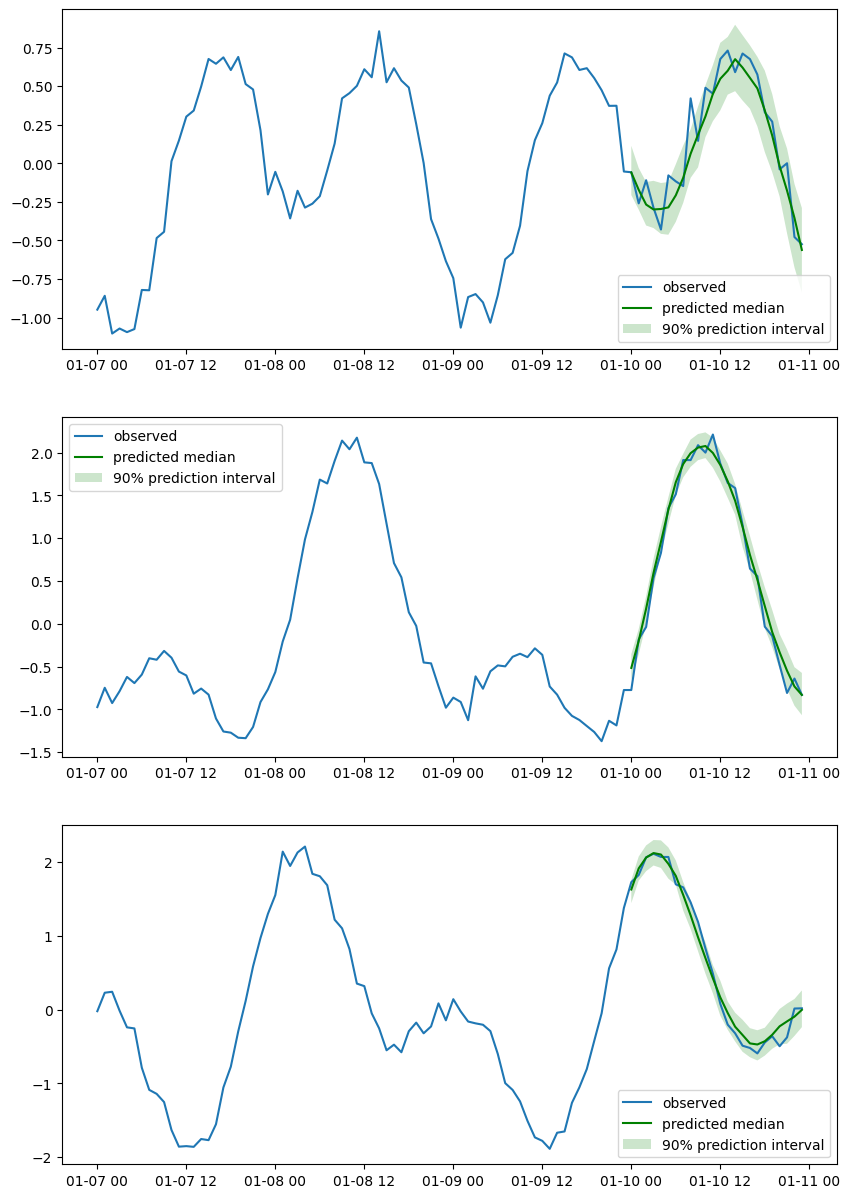

In [ ]:
n_plot = 3
indices = np.random.choice(np.arange(0, N), size=n_plot, replace=False)
fig, axes = plt.subplots(n_plot, 1, figsize=(10, n_plot * 5))
for index, ax in zip(indices, axes):
    ax.plot(tests[index][-4 * prediction_length :].to_timestamp())
    plt.sca(ax)
    forecasts[index].plot(intervals=(0.9,), color="g")
    plt.legend(["observed", "predicted median", "90% prediction interval"])